# Assignment 6: Model Evaluation, Explainability, and Fairness Reflection

**Dataset:** Vehicle Service Rebooking Dataset  
**Business goal:** Predict whether a vehicle-service customer will rebook a future service appointment.  
**Target variable:** `service_rebooked` where `1 = rebooked` and `0 = not rebooked`.

This notebook completes all required tasks: data loading, preprocessing, decision tree training, evaluation metrics, confusion matrix, error analysis, cross-validation, overfitting analysis, feature importance, SHAP, LIME, fairness/bias reflection, and final business interpretation.

## Setup and Imports

The notebook uses standard Python machine learning libraries plus SHAP and LIME for explainability. If a package is missing, uncomment and run the installation cell below.

In [1]:
# If needed, uncomment this line and run it once:
# !pip install pypdf pandas numpy scikit-learn matplotlib seaborn shap lime tabulate

In [2]:
import re
import os
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from pypdf import PdfReader
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

try:
    import shap
except Exception as e:
    shap = None
    print('SHAP unavailable:', e)

try:
    from lime.lime_tabular import LimeTabularExplainer
except Exception as e:
    LimeTabularExplainer = None
    print('LIME unavailable:', e)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
PDF_PATH = '/home/user/uploads/vehicle_service_rebooking_dataset.pdf'
OUT_DIR = 'assignment6_outputs'
os.makedirs(OUT_DIR, exist_ok=True)

## Task 1: Load and Understand the Dataset

The uploaded PDF contains the dataset split across pages. The code below extracts the rows from the PDF and converts them into a pandas DataFrame.

In [3]:
# Extract the tabular data from the uploaded PDF.
reader = PdfReader(PDF_PATH)
first_lines = []
second_lines = []

for i, page in enumerate(reader.pages):
    txt = page.extract_text() or ''
    lines = [ln.strip() for ln in txt.splitlines() if ln.strip()]
    if i < 8:
        for ln in lines:
            if ln.startswith('customer_id'):
                continue
            if ln.startswith('VS'):
                first_lines.append(ln)
    else:
        for ln in lines:
            if ln.startswith('last_service_cost'):
                continue
            second_lines.append(ln)

service_types = ['Brake Service', 'Oil Change', 'Tire Service', 'Inspection', 'Repair']
segments = ['Returning', 'Loyal', 'Fleet', 'New']

def parse_first(line):
    pattern = r'^(VS\d{4})\s+(\d+)\s+(18-25|26-35|36-50|51\+)\s+(Male|Female)\s+(North|South|East|West)\s+(Sedan|SUV|Truck|Electric|Hybrid)\s+(.+)\s+(\d+)\s+(\d+)$'
    m = re.match(pattern, line)
    if not m:
        raise ValueError(f'Cannot parse first-half line: {line}')
    customer_id, age, age_group, gender, region, vehicle_type, mid, vehicle_age, mileage = m.groups()
    mid = mid.strip()
    service_type = None
    segment = None
    for seg in segments:
        if mid.endswith(seg):
            segment = seg
            service_type = mid[:-len(seg)].strip()
            break
    if service_type not in service_types:
        for st in service_types:
            if mid.startswith(st):
                service_type = st
                segment = mid[len(st):].strip()
                break
    return {
        'customer_id': customer_id,
        'age': int(age),
        'age_group': age_group,
        'gender': gender,
        'region': region,
        'vehicle_type': vehicle_type,
        'service_type': service_type,
        'customer_segment': segment,
        'vehicle_age_years': int(vehicle_age),
        'mileage_km': int(mileage),
    }


def parse_second(line):
    toks = line.split()
    coupon = toks[-2]
    target = int(toks[-1])
    nums = toks[:-2]
    # Expected: cost, previous services, days since last service, rating, waiting time.
    # A few PDF-extracted rows have a missing previous-service value; use NaN.
    if len(nums) == 5:
        cost, nprev, days, rating, wait = nums
    elif len(nums) == 4:
        cost = nums[0]
        nprev = np.nan
        days, rating, wait = nums[1:]
    else:
        raise ValueError(f'Unexpected number of numeric fields: {line}')
    return {
        'last_service_cost': float(cost),
        'number_of_previous_services': float(nprev) if not pd.isna(nprev) else np.nan,
        'days_since_last_service': int(days),
        'service_rating': int(rating),
        'waiting_time_minutes': int(wait),
        'coupon_used': coupon,
        'service_rebooked': target,
    }

first = pd.DataFrame([parse_first(ln) for ln in first_lines])
second = pd.DataFrame([parse_second(ln) for ln in second_lines])
df = pd.concat([first.reset_index(drop=True), second.reset_index(drop=True)], axis=1)

# Save extracted dataset for reference.
df.to_csv(os.path.join(OUT_DIR, 'vehicle_service_rebooking_extracted.csv'), index=False)

display(df.head())
print('Dataset size:', df.shape)

,customer_id,age,age_group,gender,region,vehicle_type,service_type,customer_segment,vehicle_age_years,mileage_km,last_service_cost,number_of_previous_services,days_since_last_service,service_rating,waiting_time_minutes,coupon_used,service_rebooked
0,VS0001,56,51+,Male,East,Electric,Inspection,New,2,43797,1417.36,7.0,233,2,137,No,0
1,VS0002,40,36-50,Female,North,Sedan,Repair,Returning,8,57409,688.43,8.0,473,5,107,No,0
2,VS0003,45,36-50,Male,East,Hybrid,Brake Service,Returning,13,39674,217.13,9.0,394,2,25,No,0
3,VS0004,65,51+,Female,East,Hybrid,Brake Service,Returning,5,243134,1676.28,10.0,486,3,11,Yes,0
4,VS0005,48,36-50,Male,East,SUV,Repair,Returning,4,212670,557.89,18.0,314,2,121,Yes,0


Dataset size: (360, 17)


Column names:
['customer_id', 'age', 'age_group', 'gender', 'region', 'vehicle_type', 'service_type', 'customer_segment', 'vehicle_age_years', 'mileage_km', 'last_service_cost', 'number_of_previous_services', 'days_since_last_service', 'service_rating', 'waiting_time_minutes', 'coupon_used', 'service_rebooked']

Data types:


,column,data_type
0,customer_id,object
1,age,int64
2,age_group,object
3,gender,object
4,region,object
5,vehicle_type,object
6,service_type,object
7,customer_segment,object
8,vehicle_age_years,int64
9,mileage_km,int64



Missing values:


,column,missing_values
0,customer_id,0
1,age,0
2,age_group,0
3,gender,0
4,region,0
5,vehicle_type,0
6,service_type,0
7,customer_segment,0
8,vehicle_age_years,0
9,mileage_km,0



Duplicate records: 0
Duplicate customer IDs: 0

Target variable distribution:


,service_rebooked,count,percent
0,0,288,0.8
1,1,72,0.2


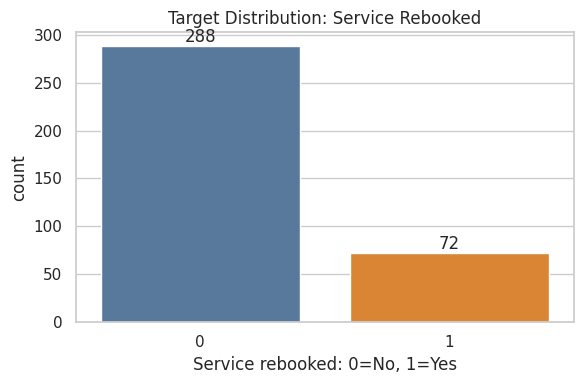

In [4]:
print('Column names:')
print(list(df.columns))

print('\nData types:')
display(pd.DataFrame({'column': df.columns, 'data_type': [str(t) for t in df.dtypes]}))

print('\nMissing values:')
display(df.isna().sum().reset_index().rename(columns={'index': 'column', 0: 'missing_values'}))

print('\nDuplicate records:', df.duplicated().sum())
print('Duplicate customer IDs:', df['customer_id'].duplicated().sum())

print('\nTarget variable distribution:')
target_dist = df['service_rebooked'].value_counts().sort_index().rename_axis('service_rebooked').reset_index(name='count')
target_dist['percent'] = target_dist['count'] / len(df)
display(target_dist)

plt.figure(figsize=(6,4))
ax = sns.countplot(data=df, x='service_rebooked', palette=['#4C78A8', '#F58518'])
ax.set_title('Target Distribution: Service Rebooked')
ax.set_xlabel('Service rebooked: 0=No, 1=Yes')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Task 1 Explanation

The dataset contains customer, vehicle, service, and appointment-history information for vehicle-service visits. The target variable is `service_rebooked`, which shows whether the customer rebooked a future appointment.

The target is **imbalanced** because most customers did not rebook. This matters because a model can appear accurate by predicting the majority class, so precision, recall, F1-score, and the confusion matrix are also needed.

## Task 2: Define Features and Target Variable

The target variable is `service_rebooked`. Identifier and group-related fairness columns are removed from model training.

In [5]:
target_col = 'service_rebooked'
identifier_cols = ['customer_id']
fairness_cols = ['gender', 'age_group', 'region']

# age is also removed because it is a direct demographic variable and closely related to age_group.
removed_from_model = identifier_cols + fairness_cols + ['age']
feature_cols = [c for c in df.columns if c not in removed_from_model + [target_col]]

X = df[feature_cols].copy()
y = df[target_col].copy()
groups = df[fairness_cols].copy()

print('Target variable:', target_col)
print('\nInput features used by the model:')
print(feature_cols)
print('\nRemoved from model input:')
print(removed_from_model)
print('\nKept only for fairness reflection:')
print(fairness_cols)

Target variable: service_rebooked

Input features used by the model:
['vehicle_type', 'service_type', 'customer_segment', 'vehicle_age_years', 'mileage_km', 'last_service_cost', 'number_of_previous_services', 'days_since_last_service', 'service_rating', 'waiting_time_minutes', 'coupon_used']

Removed from model input:
['customer_id', 'gender', 'age_group', 'region', 'age']

Kept only for fairness reflection:
['gender', 'age_group', 'region']


## Task 3: Data Preprocessing

Preprocessing is necessary because machine learning models need numeric inputs and cannot directly understand text categories such as `SUV`, `Oil Change`, or `Loyal`. Missing values must also be handled before training.

In [6]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(exclude=['int64', 'float64']).columns.tolist()

preprocess = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
], remainder='drop')

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['vehicle_age_years', 'mileage_km', 'last_service_cost', 'number_of_previous_services', 'days_since_last_service', 'service_rating', 'waiting_time_minutes']
Categorical features: ['vehicle_type', 'service_type', 'customer_segment', 'coupon_used']


## Task 4: Train/Test Split

The data is split into training data and testing data. Training data teaches the model, while testing data evaluates how the model performs on unseen records.

In [7]:
X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X, y, groups, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print('Training set size:', len(X_train))
print('Testing set size:', len(X_test))
print('Training target distribution:')
display(y_train.value_counts(normalize=True).sort_index().rename('proportion').reset_index())
print('Testing target distribution:')
display(y_test.value_counts(normalize=True).sort_index().rename('proportion').reset_index())

Training set size: 270
Testing set size: 90
Training target distribution:


,service_rebooked,proportion
0,0,0.8
1,1,0.2


Testing target distribution:


,service_rebooked,proportion
0,0,0.8
1,1,0.2


## Task 5: Train a Classification Model

A simple Decision Tree Classifier is trained. The tree learns rules that separate customers predicted to rebook from customers predicted not to rebook.

In [8]:
model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE, class_weight='balanced')
pipe = Pipeline([('preprocess', preprocess), ('model', model)])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

comparison = X_test.copy()
comparison['actual_service_rebooked'] = y_test.values
comparison['predicted_service_rebooked'] = y_pred
comparison['prediction_probability_rebooked'] = np.round(y_proba, 4)
comparison['correct_status'] = np.where(comparison['actual_service_rebooked'] == comparison['predicted_service_rebooked'], 'Correct', 'Incorrect')

print('First 10 actual vs predicted values:')
display(comparison[['actual_service_rebooked', 'predicted_service_rebooked', 'prediction_probability_rebooked', 'correct_status']].head(10))

First 10 actual vs predicted values:


,actual_service_rebooked,predicted_service_rebooked,prediction_probability_rebooked,correct_status
269,0,0,0.0000,Correct
319,1,1,0.9778,Correct
203,0,1,0.9032,Incorrect
229,0,1,0.9778,Incorrect
73,0,0,0.0000,Correct
247,1,1,0.9778,Correct
65,0,0,0.0769,Correct
346,0,0,0.4211,Correct
318,1,1,0.9778,Correct
14,0,0,0.0000,Correct


### Task 5 Explanation

The model is trying to learn which service and customer-behavior patterns are associated with rebooking. The comparison table shows whether the first few predictions are correct or incorrect. Some predictions can be wrong, so the model must be evaluated with formal metrics.

## Task 6: Evaluate the Model

Accuracy alone is not enough because the target variable is imbalanced. Precision, recall, and F1-score provide a better evaluation.

In [9]:
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1-score': f1_score(y_test, y_pred, zero_division=0),
}
metrics_df = pd.DataFrame({'Metric': metrics.keys(), 'Value': metrics.values()})
display(metrics_df)

,Metric,Value
0,Accuracy,0.788889
1,Precision,0.480000
2,Recall,0.666667
3,F1-score,0.558140


### Task 6 Explanation

- **Accuracy** means the percentage of total predictions that were correct.
- **Precision** means that when the model predicts rebooking, how often it is right.
- **Recall** means that out of all customers who actually rebooked, how many the model found.
- **F1-score** balances precision and recall.

For this business problem, **recall** is especially important because the business wants to find customers who are likely to rebook. Missing these customers can mean lost follow-up and revenue opportunities.

## Task 7: Confusion Matrix

,Predicted 0: Not Rebooked,Predicted 1: Rebooked
Actual 0: Not Rebooked,59,13
Actual 1: Rebooked,6,12


True Negative: 59
False Positive: 13
False Negative: 6
True Positive: 12


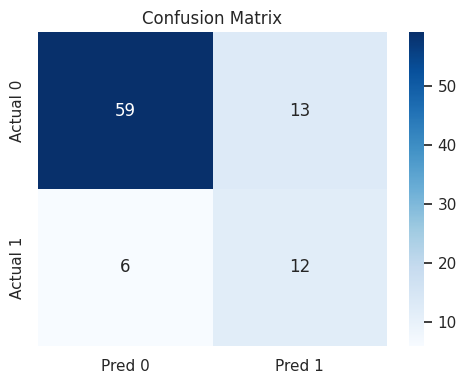

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame(
    cm,
    index=['Actual 0: Not Rebooked', 'Actual 1: Rebooked'],
    columns=['Predicted 0: Not Rebooked', 'Predicted 1: Rebooked']
)
display(cm_df)
print(f'True Negative: {tn}')
print(f'False Positive: {fp}')
print(f'False Negative: {fn}')
print(f'True Positive: {tp}')

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Task 7 Explanation

- **True Negative:** Customer did not rebook and the model predicted not rebooked.
- **False Positive:** Customer did not rebook but the model predicted rebooked.
- **False Negative:** Customer rebooked but the model predicted not rebooked.
- **True Positive:** Customer rebooked and the model predicted rebooked.

A false positive may waste marketing or staff time on customers who will not rebook. A false negative may cause the business to miss customers who actually would rebook. For this dataset, **false negatives are more serious** because they can represent missed service revenue opportunities.

## Task 8: Error Analysis

,error_type,count
0,True Negative,59
1,False Positive,13
2,True Positive,12
3,False Negative,6


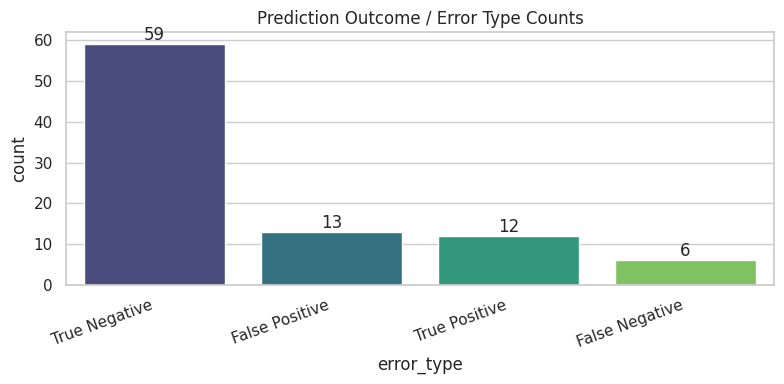

Wrong predictions:


,actual_service_rebooked,predicted_service_rebooked,prediction_probability_rebooked,error_type,vehicle_type,service_type,customer_segment,vehicle_age_years,mileage_km,last_service_cost,number_of_previous_services,days_since_last_service,service_rating,waiting_time_minutes,coupon_used
203,0,1,0.9032,False Positive,Truck,Inspection,New,14,86197,709.01,5.0,102,1,19,No
229,0,1,0.9778,False Positive,Hybrid,Tire Service,Returning,11,106179,183.05,8.0,138,3,111,Yes
207,0,1,0.8696,False Positive,Electric,Oil Change,New,2,218997,1400.85,14.0,204,2,143,No
171,1,0,0.0000,False Negative,Sedan,Tire Service,Loyal,4,14567,569.13,5.0,169,4,102,Yes
265,0,1,0.9778,False Positive,Sedan,Oil Change,Returning,4,117885,287.95,8.0,135,4,29,Yes
358,0,1,0.9032,False Positive,Electric,Repair,Returning,9,246619,917.65,3.0,114,2,84,No
260,1,0,0.0769,False Negative,Electric,Brake Service,Fleet,4,88216,1753.79,10.0,316,5,108,No
227,1,0,0.0000,False Negative,Sedan,Inspection,Loyal,6,60138,1193.24,4.0,220,5,65,Yes
158,0,1,0.8696,False Positive,Sedan,Tire Service,Loyal,6,126155,1568.48,15.0,277,5,143,Yes
87,0,1,0.9032,False Positive,Sedan,Repair,New,8,130026,88.33,10.0,60,1,62,Yes


In [11]:
comparison['error_type'] = np.select(
    [
        (comparison['actual_service_rebooked'] == 0) & (comparison['predicted_service_rebooked'] == 0),
        (comparison['actual_service_rebooked'] == 0) & (comparison['predicted_service_rebooked'] == 1),
        (comparison['actual_service_rebooked'] == 1) & (comparison['predicted_service_rebooked'] == 0),
        (comparison['actual_service_rebooked'] == 1) & (comparison['predicted_service_rebooked'] == 1),
    ],
    ['True Negative', 'False Positive', 'False Negative', 'True Positive'],
    default='Unknown'
)

error_counts = comparison['error_type'].value_counts().rename_axis('error_type').reset_index(name='count')
display(error_counts)

plt.figure(figsize=(8,4))
ax = sns.barplot(data=error_counts, x='error_type', y='count', palette='viridis')
plt.title('Prediction Outcome / Error Type Counts')
plt.xticks(rotation=20, ha='right')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

wrong_predictions = comparison[comparison['correct_status'] == 'Incorrect'].copy()
print('Wrong predictions:')
display(wrong_predictions[['actual_service_rebooked', 'predicted_service_rebooked', 'prediction_probability_rebooked', 'error_type'] + feature_cols].head(10))

### Task 8 Explanation

The most common wrong-prediction type should be reviewed from the error count table. If false positives are most common, the business may waste outreach resources. If false negatives are most common, the business may miss likely rebooking customers. The business impact depends on which error is more expensive.

## Task 9: Cross-Validation

Cross-validation tests whether the model performance is stable across different splits of the data.

,Fold,Accuracy
0,1,0.777778
1,2,0.750000
2,3,0.847222
3,4,0.791667
4,5,0.791667


Mean cross-validation accuracy: 0.792
Standard deviation: 0.032


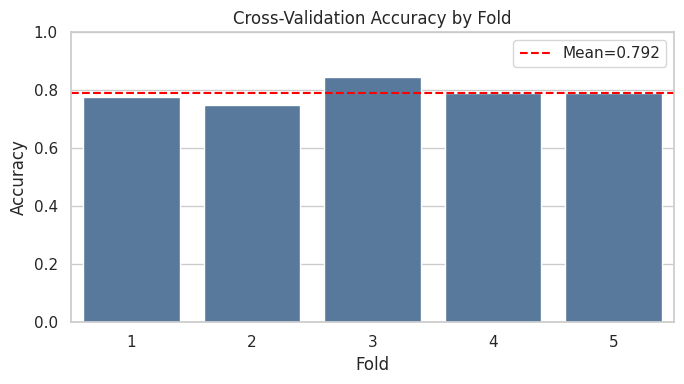

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy')
cv_df = pd.DataFrame({'Fold': range(1, len(cv_scores)+1), 'Accuracy': cv_scores})
display(cv_df)
print('Mean cross-validation accuracy:', round(cv_scores.mean(), 3))
print('Standard deviation:', round(cv_scores.std(), 3))

plt.figure(figsize=(7,4))
ax = sns.barplot(data=cv_df, x='Fold', y='Accuracy', color='#4C78A8')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.3f}')
plt.ylim(0, 1)
plt.title('Cross-Validation Accuracy by Fold')
plt.legend()
plt.tight_layout()
plt.show()

### Task 9 Explanation

The model is more stable when the fold accuracies are close together and the standard deviation is low. A high standard deviation would mean the model performs differently depending on which records are used for training and testing.

## Task 10: Overfitting and Underfitting Analysis

Training accuracy is compared with testing accuracy. Different tree depths are also tested.

Training accuracy: 0.944
Testing accuracy: 0.789


,max_depth,training_accuracy,testing_accuracy
0,1,0.803704,0.766667
1,2,0.774074,0.633333
2,3,0.859259,0.744444
3,4,0.874074,0.733333
4,5,0.944444,0.788889
5,6,0.955556,0.788889
6,7,0.992593,0.777778
7,8,1.000000,0.800000
8,9,1.000000,0.800000
9,10,1.000000,0.800000


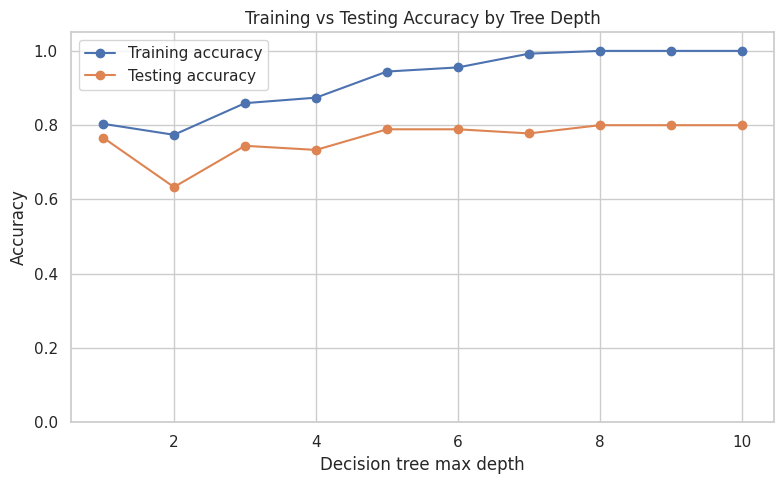

In [13]:
train_acc = accuracy_score(y_train, pipe.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
print('Training accuracy:', round(train_acc, 3))
print('Testing accuracy:', round(test_acc, 3))

depth_rows = []
for depth in range(1, 11):
    depth_pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE, class_weight='balanced'))
    ])
    depth_pipe.fit(X_train, y_train)
    depth_rows.append({
        'max_depth': depth,
        'training_accuracy': accuracy_score(y_train, depth_pipe.predict(X_train)),
        'testing_accuracy': accuracy_score(y_test, depth_pipe.predict(X_test)),
    })

depth_df = pd.DataFrame(depth_rows)
display(depth_df)

plt.figure(figsize=(8,5))
plt.plot(depth_df['max_depth'], depth_df['training_accuracy'], marker='o', label='Training accuracy')
plt.plot(depth_df['max_depth'], depth_df['testing_accuracy'], marker='o', label='Testing accuracy')
plt.ylim(0, 1.05)
plt.xlabel('Decision tree max depth')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy by Tree Depth')
plt.legend()
plt.tight_layout()
plt.show()

### Task 10 Explanation

A model is overfitting when training accuracy is much higher than testing accuracy. A model is underfitting when both training and testing accuracy are low. Deeper trees can memorize the training data, so limiting tree depth helps reduce overfitting.

## Task 11: Feature Importance

,feature,importance
3,number_of_previous_services,0.359034
4,days_since_last_service,0.325850
6,waiting_time_minutes,0.145288
2,last_service_cost,0.090399
0,vehicle_age_years,0.047237
5,service_rating,0.021185
1,mileage_km,0.011007
7,vehicle_type_Electric,0.000000
8,vehicle_type_Hybrid,0.000000
9,vehicle_type_SUV,0.000000


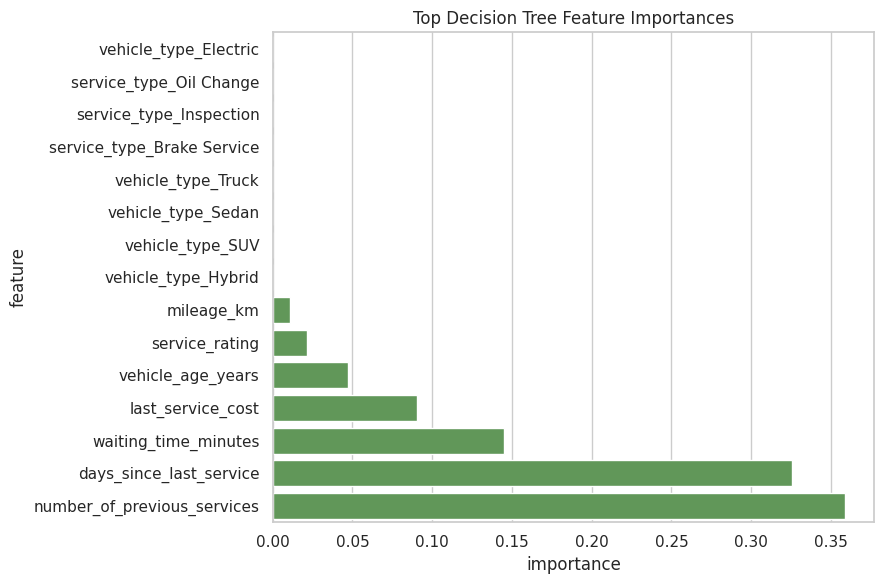

In [14]:
feature_names = pipe.named_steps['preprocess'].get_feature_names_out()
feature_names = [n.replace('num__', '').replace('cat__', '') for n in feature_names]
importances = pipe.named_steps['model'].feature_importances_
fi = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)

display(fi.head(15))

plt.figure(figsize=(9,6))
fi_top = fi.head(15).sort_values('importance')
sns.barplot(data=fi_top, x='importance', y='feature', color='#59A14F')
plt.title('Top Decision Tree Feature Importances')
plt.tight_layout()
plt.show()

### Task 11 Explanation

The most important features are the variables the decision tree used most to split customers into prediction groups. These features may represent service history, customer experience, and service context.

Feature importance does **not** prove cause and effect. It only shows which features were useful for prediction in this dataset.

## Task 12: SHAP Explanation

SHAP explains how each feature contributes toward or away from a model prediction.

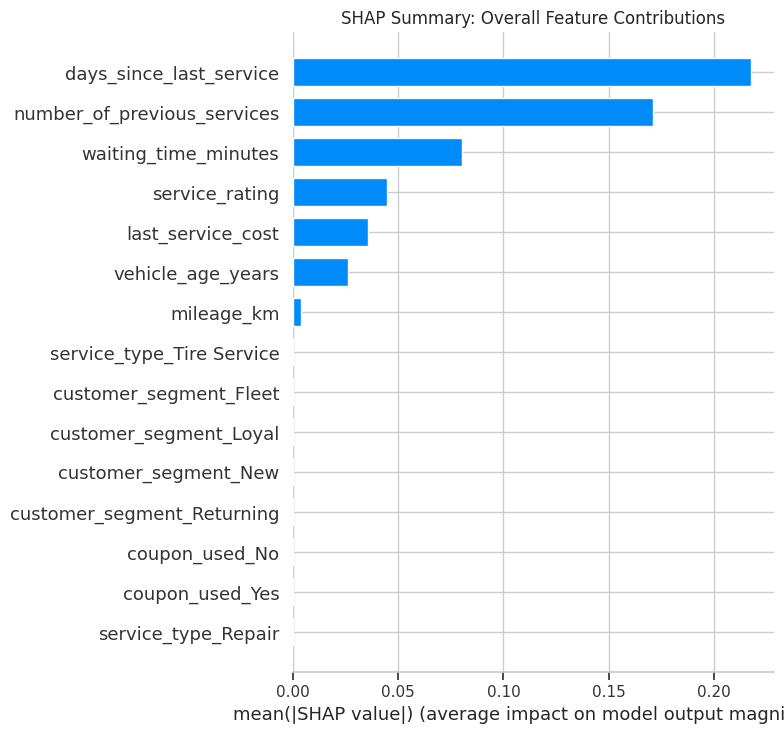

Selected record actual value: 0
Selected record predicted value: 0
Predicted probability of rebooking: 0.0


,feature,transformed_value,shap_contribution_to_rebooked,abs_contribution
0,vehicle_age_years,17.00,-0.285347,0.285347
3,number_of_previous_services,14.00,0.118672,0.118672
6,waiting_time_minutes,123.00,-0.111892,0.111892
2,last_service_cost,1628.65,-0.099875,0.099875
4,days_since_last_service,163.00,-0.061470,0.061470
5,service_rating,1.00,-0.060884,0.060884
1,mileage_km,58346.00,0.000794,0.000794
7,vehicle_type_Electric,0.00,0.000000,0.000000
8,vehicle_type_Hybrid,0.00,0.000000,0.000000
9,vehicle_type_SUV,1.00,0.000000,0.000000


In [15]:
X_train_t = pipe.named_steps['preprocess'].transform(X_train)
X_test_t = pipe.named_steps['preprocess'].transform(X_test)
selected_pos = 0

if shap is not None:
    explainer = shap.TreeExplainer(pipe.named_steps['model'])
    shap_values = explainer.shap_values(X_test_t)
    if isinstance(shap_values, list):
        sv_pos = shap_values[1]
    elif getattr(shap_values, 'ndim', 0) == 3:
        sv_pos = shap_values[:, :, 1]
    else:
        sv_pos = shap_values

    shap.summary_plot(sv_pos, X_test_t, feature_names=feature_names, show=False, plot_type='bar', max_display=15)
    plt.title('SHAP Summary: Overall Feature Contributions')
    plt.tight_layout()
    plt.show()

    shap_record_df = pd.DataFrame({
        'feature': feature_names,
        'transformed_value': X_test_t[selected_pos],
        'shap_contribution_to_rebooked': sv_pos[selected_pos],
    })
    shap_record_df['abs_contribution'] = shap_record_df['shap_contribution_to_rebooked'].abs()
    shap_record_df = shap_record_df.sort_values('abs_contribution', ascending=False)

    print('Selected record actual value:', int(y_test.iloc[selected_pos]))
    print('Selected record predicted value:', int(y_pred[selected_pos]))
    print('Predicted probability of rebooking:', round(float(y_proba[selected_pos]), 3))
    display(shap_record_df.head(10))
else:
    print('SHAP is not available in this environment.')

### Task 12 Explanation

Positive SHAP values push the prediction toward `1` / rebooked. Negative SHAP values push the prediction toward `0` / not rebooked. SHAP helps beyond basic feature importance because it can explain both overall model behavior and individual predictions.

## Task 13: LIME Explanation

LIME explains one individual prediction by building a simple local explanation around that specific record.

Probability of not rebooking: 1.0
Probability of rebooking: 0.0


,feature_condition,lime_weight_for_rebooked
0,days_since_last_service <= 175.75,0.446823
1,number_of_previous_services > 13.00,0.203097
2,service_rating <= 2.00,-0.080866
3,92.00 < waiting_time_minutes <= 129.75,-0.033453
4,last_service_cost > 1328.53,-0.029905
5,vehicle_age_years > 14.00,-0.022611
6,service_type_Tire Service <= 0.00,-0.016069
7,service_type_Inspection > 0.00,0.014147
8,customer_segment_Returning <= 0.00,0.013464
9,coupon_used_No <= 0.00,0.009465


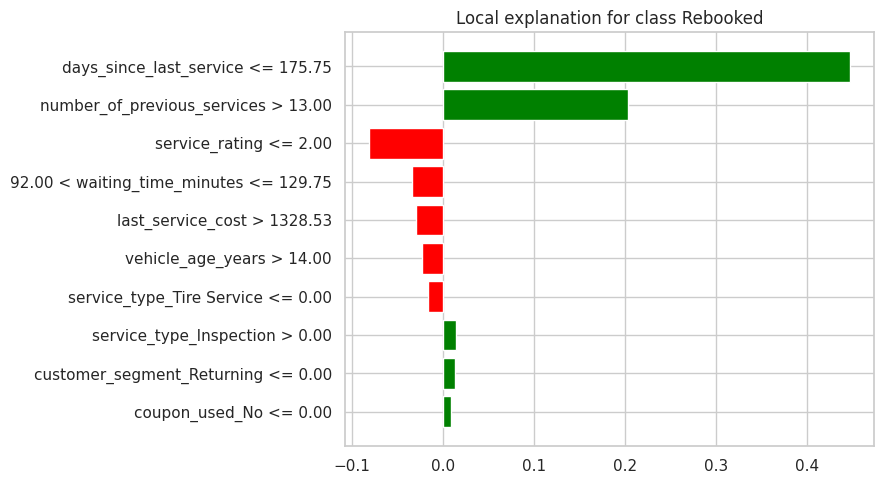

In [16]:
if LimeTabularExplainer is not None:
    lime_explainer = LimeTabularExplainer(
        training_data=np.array(X_train_t),
        feature_names=feature_names,
        class_names=['Not rebooked', 'Rebooked'],
        mode='classification',
        discretize_continuous=True,
        random_state=RANDOM_STATE
    )
    exp = lime_explainer.explain_instance(X_test_t[selected_pos], pipe.named_steps['model'].predict_proba, num_features=10)
    lime_df = pd.DataFrame(exp.as_list(), columns=['feature_condition', 'lime_weight_for_rebooked'])

    print('Probability of not rebooking:', round(1 - float(y_proba[selected_pos]), 3))
    print('Probability of rebooking:', round(float(y_proba[selected_pos]), 3))
    display(lime_df)

    fig = exp.as_pyplot_figure()
    fig.set_size_inches(9, 5)
    plt.tight_layout()
    plt.show()
else:
    print('LIME is not available in this environment.')

### Task 13 Explanation

Positive LIME weights support the prediction of rebooking. Negative LIME weights work against rebooking and support not rebooking. LIME is useful for business users because it gives a short explanation for one specific model decision.

## Task 14: Fairness and Bias Reflection

Fairness is analyzed across group-related columns. These group columns were not used directly as model input.

,group_column,group_value,records,actual_positive_rate,predicted_positive_rate,accuracy_by_group
0,gender,Female,47,0.234043,0.297872,0.765957
1,gender,Male,43,0.162791,0.255814,0.813953
2,age_group,18-25,11,0.181818,0.363636,0.636364
3,age_group,26-35,11,0.272727,0.272727,1.000000
4,age_group,36-50,31,0.225806,0.258065,0.774194
5,age_group,51+,37,0.162162,0.270270,0.783784
6,region,East,17,0.117647,0.235294,0.764706
7,region,North,24,0.125000,0.208333,0.833333
8,region,South,24,0.291667,0.333333,0.791667
9,region,West,25,0.240000,0.320000,0.760000


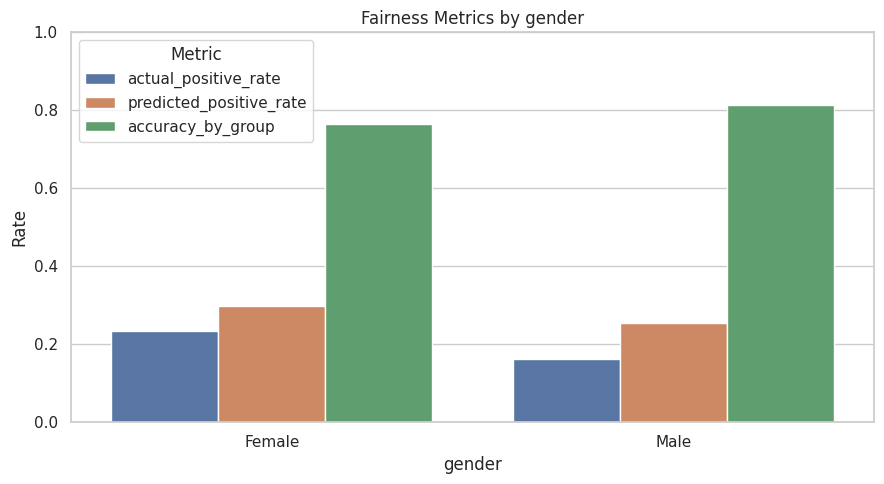

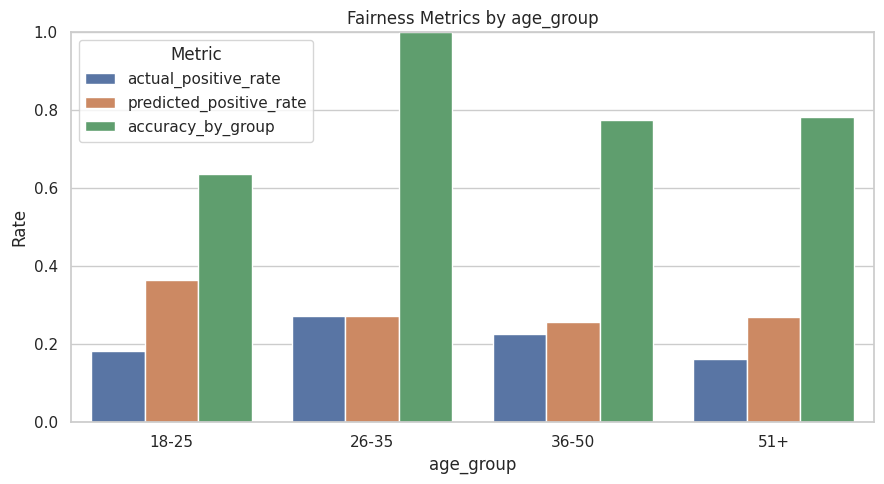

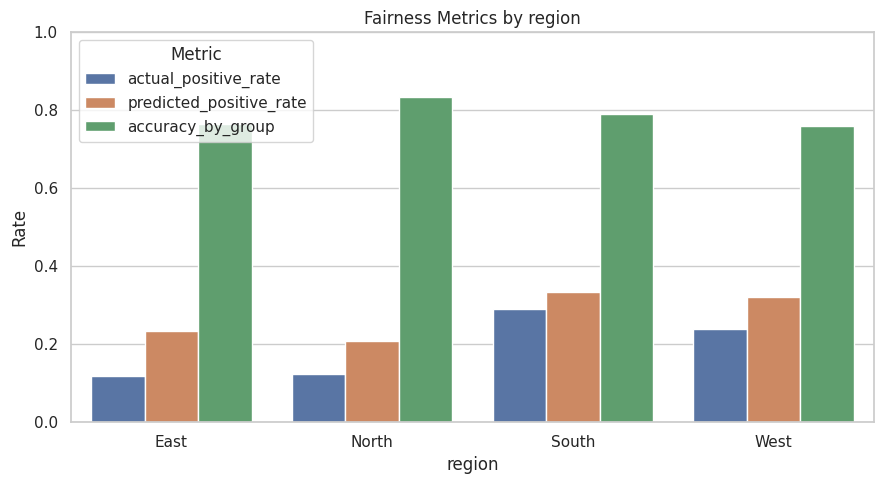

In [17]:
fair_test = groups_test.copy().reset_index(drop=True)
fair_test['actual'] = y_test.reset_index(drop=True)
fair_test['predicted'] = pd.Series(y_pred)
fair_test['correct'] = (fair_test['actual'] == fair_test['predicted']).astype(int)

fair_rows = []
for col in fairness_cols:
    for val, sub in fair_test.groupby(col):
        fair_rows.append({
            'group_column': col,
            'group_value': val,
            'records': len(sub),
            'actual_positive_rate': sub['actual'].mean(),
            'predicted_positive_rate': sub['predicted'].mean(),
            'accuracy_by_group': sub['correct'].mean(),
        })

fairness_df = pd.DataFrame(fair_rows)
display(fairness_df)

for col in fairness_cols:
    sub = fairness_df[fairness_df['group_column'] == col].copy()
    melted = sub.melt(
        id_vars=['group_column', 'group_value', 'records'],
        value_vars=['actual_positive_rate', 'predicted_positive_rate', 'accuracy_by_group'],
        var_name='metric',
        value_name='value'
    )
    plt.figure(figsize=(9,5))
    sns.barplot(data=melted, x='group_value', y='value', hue='metric')
    plt.ylim(0, 1)
    plt.title(f'Fairness Metrics by {col}')
    plt.xlabel(col)
    plt.ylabel('Rate')
    plt.legend(title='Metric')
    plt.tight_layout()
    plt.show()

### Task 14 Reflection

The fairness table compares number of records, actual positive rate, predicted positive rate, and accuracy by group. If one group has much lower accuracy or receives fewer positive predictions than expected, the model may create unfair business outcomes.

The group-level sample sizes are relatively small, so these fairness findings should be treated as an early warning rather than final proof of bias. Even though `gender`, `age_group`, and `region` were removed from the model inputs, other variables can still act as proxies. The business should continue monitoring fairness before using the model for real decisions.

## Task 15: Final Business Interpretation

This model predicts whether a vehicle-service customer will rebook a future service appointment. The model has reasonable overall accuracy for a first prototype, but the target is imbalanced, so recall and F1-score are more informative than accuracy alone.

The most important metric for this business problem is **recall**, because the business wants to identify as many likely rebooking customers as possible. False negatives are especially serious because they represent customers who actually rebooked but were not identified by the model. This could reduce follow-up opportunities and future service revenue. False positives can also create waste by sending offers or reminders to customers who will not rebook.

The overfitting analysis shows that deeper decision trees may memorize the training data without improving testing performance. The selected tree limits depth, but the gap between training and testing performance means the model should still be treated cautiously.

Feature importance, SHAP, and LIME help explain the model. The important features mainly relate to customer service behavior, previous service history, service context, and customer experience. However, feature importance and explainability methods do **not** prove cause and effect.

Fairness analysis across gender, age group, and region shows that group-level performance should be monitored carefully. Unequal predicted positive rates or accuracies could lead to unfair business decisions, especially if some groups receive fewer service reminders or rebooking offers.

### Final Recommendation

This model is **only suitable as an early prototype**. It is not ready for full real business use yet. Before deployment, the business should collect more data, tune the model and decision threshold, compare other algorithms, improve recall, and perform a larger fairness review.